[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/10_simulation_based_inference/exercise.ipynb)

# Session 10 - Simulation-based inference

In this exercise, we will get a chance to practice parameterizing from a simulation (instead of from a formula-based parametric model).

The background for the example:

In  1943, Luria and Delbrück were settling an argument about whether bacteria adapt or mutate. E. coli exposed to phage T1 mostly die, but a few
  colonies survive and are resistant. Two explanations were being debated at the time:

  - Induced (the "Lamarckian" option): exposure to the phage causes resistance. Each cell, on contact, has some small independent chance
    of converting.
  - Spontaneous (the Darwinian one): resistance mutations happen at random during ordinary growth, long before any phage shows up, and the
    phage merely reveals who already had one.

  The two hypotheses predict the same average number of resistant colonies, but differ in the shape of the distribution they produce.

  The test is to grow many small cultures in parallel, each from a few cells, each in its own tube. Let them grow up. Then plate each culture separately
  onto phage plates and count resistant colonies per culture.

  - If resistance is induced at plating, every cell gets an independent coin flip at the same moment. Counts across tubes are Poisson:
    variance equals mean. Twenty tubes give you 5, 7, 4, 6, 5, 8...
  - If mutations arise during growth, then the timing of the mutation matters since a mutation in the first generation gets copied into half
    the final culture. A mutation in the last generation gives you one resistant cell. Counts across tubes come out 0, 0, 1, 0, 2, 0, 0,
    638, 0, 1. Luria named this mechanic "jackpot" inspired by how a slot machine works.

  They saw jackpots. Resistance is present prior to selection. Nobel Prize, 1969. It is also, incidentally, one of the first times anyone inferred
  an invisible biological mechanism purely from the shape of a distribution rather than from its mean, so this is a great example for the philosophy of this course.

The generator, the data, the checks and the figures are written already. Three cells are left blank: the growth loop inside the simulator, the loop that fixes the tolerance, and the walk inside the sampler.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, together with the seed its figures were produced from.

## 1. Setup

Four functions written in earlier exercises are given here in full: the linear congruential generator, the sample mean, the sample standard deviation and the normal density. Nothing below needs a package beyond `math` and `matplotlib`.

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def mean(values):
    """The sample mean, the sum over the list divided by its length."""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)


def std(values):
    """The sample standard deviation, the root of the average squared deviation from the mean."""
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5


def normal(x, mu, sigma):
    """f(x | mu, sigma) = exp(-(x - mu)^2 / (2 sigma^2)) / (sigma sqrt(2 pi))"""
    return math.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / (sigma * (2 * math.pi) ** 0.5)


print("ok, setup")


ok, setup


## 2. The experiment

Here we have some (synthetic) observation data from the bacterial growth experiment: 20 cultures grown for 12 generations from single cells. The observed data represent the number of resistant colonies counted  in each parallel experiment.

In [2]:
GENERATIONS = 12
CELLS = 2 ** GENERATIONS
CULTURES = 20

observed = [0, 12, 8, 6, 3, 7, 10, 0, 0, 1, 8, 0, 2, 4, 0, 4, 128, 2, 2, 0]

assert len(observed) == CULTURES, len(observed)
print("cultures:", CULTURES, "  cells per culture:", CELLS)
print("resistant colonies per culture:", observed)


cultures: 20   cells per culture: 4096
resistant colonies per culture: [0, 12, 8, 6, 3, 7, 10, 0, 0, 1, 8, 0, 2, 4, 0, 4, 128, 2, 2, 0]


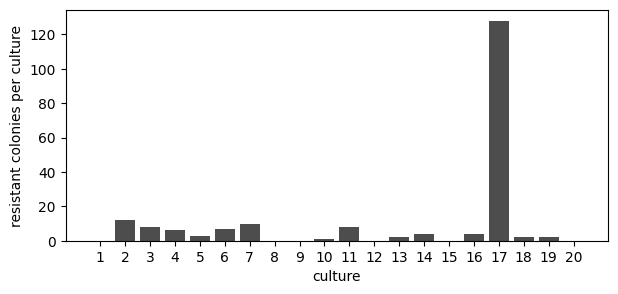

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(1, CULTURES + 1), observed, color="0.3")
ax.set_xlabel("culture")
ax.set_ylabel("resistant colonies per culture")
ax.set_xticks(range(1, CULTURES + 1))
plt.show()


## 3. The fluctuation signature

The two hypotheses make the same prediction for the average count and different predictions for how far the counts scatter around it. Write $k_c$ for the resistant colonies counted in culture $c$, one number per tube, $c = 1, \dots, C$.

Under the induced hypothesis every cell is tested once, at plating, and those tests are independent, so counts are Poisson and variance equals mean,

$$k_c \sim \text{Poisson}(\lambda), \qquad \operatorname{Var}(k) = E(k) = \lambda$$

Under the spontaneous hypothesis an early mutation is inherited by half the culture, so a few tubes carry enormous counts and the variance runs far above the mean. The cell below takes the sample mean and the sample variance of the counts, both plug-in estimates of the kind written in an earlier exercise, and divides one by the other. That ratio is the fluctuation index: induced resistance predicts a value near 1, and anything far above it is a jackpot. This ratio is the whole experiment, and it is the one number that separates the two explanations.

In [4]:
m_obs = mean(observed)
v_obs = 0.0
for c in observed:
    v_obs = v_obs + (c - m_obs) ** 2
v_obs = v_obs / (len(observed) - 1)

print(f"mean     {m_obs:8.2f} colonies per culture")
print(f"variance {v_obs:8.2f} colonies^2 per culture^2")
print(f"variance / mean {v_obs / m_obs:6.1f}")

assert v_obs / m_obs > 10, v_obs / m_obs
print("ok, variance runs far above mean, which a Poisson cannot do")


mean         9.85 colonies per culture
variance   787.08 colonies^2 per culture^2
variance / mean   79.9
ok, variance runs far above mean, which a Poisson cannot do


## 4. The simulator

Since a direct fit to the data requires a parametric model that we do not have or know, we will instead go the route of simulating the underlying mechanic.
Here we can describe the system and its components mechanistically:

  One culture:

  - start with a handful of sensitive cells, grow by doubling for $G$ generations to $N = 2^G$ cells
  - at each cell division, each daughter mutates to resistant with probability $\mu$
  - mutants are resistant forever, and their descendants are too, so a mutation at generation $g$ contributes $2^{G-g}$ resistant cells at
    the end
  - count resistant cells

  Repeat for $C$ parallel cultures. The observed data is a vector of $C$ counts. The parameter is $\mu$, the mutation rate per cell
  division, which is what you actually want to know and cannot see directly.


  Let's build the simulation, making use of our random number generator lcg function: In this problem, you should complete the loop that grows one culture and counts the resistant cells it ends up with.

**Fill the gap to grow the cultures and count the mutants.** `simulate` receives
`log10_mu` and the generator state. The rate `mu` and the list `counts`, one slot per
culture, are set up, and the function returns `counts` and the state it ended on. Write a
pass per culture, and inside it a pass per generation. Hold two numbers for the culture:
`sensitive`, starting at 1, and `mutants`, starting at 0. In a generation, every sensitive
cell divides, so draw one number on $[0, 1)$ per sensitive cell with
`state = lcg(state, A_LCG, C_LCG, M_LCG)` and `r = state / M_LCG`, and count a new mutant
when `r < mu`. Then the generation ends: the mutants that were already there double, the
new ones join them, and the sensitive cells double except for the ones that threw a mutant
daughter. Store the culture's final `mutants` in `counts`.

In [5]:
def simulate(log10_mu, state):
    """Grow CULTURES cultures from 1 cell for GENERATIONS doublings at mutation rate
    10 ** log10_mu per division, and return the resistant count per culture and the
    generator state."""
    mu = 10 ** log10_mu
    counts = [0] * CULTURES
    for i in range(CULTURES):
        sensitive = 1
        mutants = 0
        for j in range(GENERATIONS):
            new_mutants = 0
            for _ in range(sensitive):
                state = lcg(state, A_LCG, C_LCG, M_LCG)
                r = state / M_LCG
                if r < mu:
                    new_mutants += 1
            mutants = 2 * mutants + new_mutants
            sensitive = 2 * sensitive - new_mutants
        counts[i] = mutants

    return counts, state


In [6]:
counts_check, state_check = simulate(-9.0, 20260401)
assert sum(counts_check) == 0, counts_check
print("at a rate of 1e-9 per division:", counts_check)

counts_check, state_check = simulate(-0.30, state_check)
for c in counts_check:
    assert c > CELLS * 0.3, c
print("at a rate of 0.5 per division, every culture is mostly resistant:", counts_check[:4], "...")

counts_check, state_check = simulate(-3.50, state_check)
m_sim = mean(counts_check)
v_sim = 0.0
for c in counts_check:
    v_sim = v_sim + (c - m_sim) ** 2
v_sim = v_sim / (len(counts_check) - 1)
print(f"at a rate of 3.2e-4 per division: mean {m_sim:.2f}, variance / mean {v_sim / m_sim:.1f}")
print("simulated:", counts_check)
print("ok, the simulator reproduces the fluctuation signature")


at a rate of 1e-9 per division: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
at a rate of 0.5 per division, every culture is mostly resistant: [3919, 4006, 4011, 4070] ...
at a rate of 3.2e-4 per division: mean 4.70, variance / mean 6.6
simulated: [8, 0, 1, 2, 1, 18, 6, 2, 2, 9, 0, 2, 1, 0, 1, 4, 18, 8, 1, 10]
ok, the simulator reproduces the fluctuation signature


## 5. The summary statistic

The basis for approximating the posterior distribution of a parameter is comparison of summary statistics (e.g. like the mean).
In this case the mean is a poor choice. A single jackpot tube moves it by a factor of several, so two repeats of the same experiment at the same mutation rate report means that disagree wildly, and a statistic that unsteady cannot tell two mutation rates apart.

The statistic used here instead is $p_0$, the fraction of cultures with no resistant colonies at all, which is the $S(x)$ of the acceptance rule below. A culture ends up empty when no mutation happened anywhere in its lineage. A culture reaching $N$ cells took about $N$ divisions to get there, with an independent chance $\mu$ of a mutation at every one, so empty cultures are the zero class of a Poisson with mean $\mu N$,

$$P(k_c = 0) = e^{-\mu N}$$

whatever the jackpots did, because how large a clone grew does not change whether it exists. So $p_0$ depends on how often mutations occur and not on how far clones were amplified. Inverting the expression gives a mutation rate straight from the data,

$$\mu = -\frac{\ln p_0}{N}$$

and the cell below uses it to fix a reference rate for the next section.

In [7]:
def fraction_zero(counts):
    """p0, the fraction of cultures with no resistant colonies at all."""
    empty = 0
    for c in counts:
        if c == 0:
            empty = empty + 1
    return empty / len(counts)


s_observed = fraction_zero(observed)
REFERENCE = math.log10(-math.log(s_observed) / CELLS)

print(f"p0 observed: {s_observed:.3f}")
print(f"a rate of {10 ** REFERENCE:.2e} per division leaves a fraction {s_observed:.2f} of cultures empty")
print(f"REFERENCE = {REFERENCE:.3f} in log10")
assert abs(s_observed - 0.30) < 1e-9, s_observed
print("ok")


p0 observed: 0.300
a rate of 2.94e-04 per division leaves a fraction 0.30 of cultures empty
REFERENCE = -3.532 in log10
ok


## 6. Choosing a tolerance

The tolerance should not be chosen arbitrarily, since this actually influences the posterior approximation, and thus the confidence interval on our parameter.
To anchor the tolerance we ask how much the summary statistic moves when nothing about the model changes at all. Repeating the whole experiment at one fixed mutation rate gives a different $p_0$ every time, purely from the randomness of growth and plating, and the spread of those values is the resolution of the measurement. A tolerance below that spread demands agreement finer than the experiment can resolve, and the posterior it produces is narrow for no reason. So $\varepsilon$ is set to the standard deviation of $p_0$ across repeats at one fixed rate. The same loop settles the choice of the previous section, by collecting the mean alongside $p_0$ and reporting how far each of them wanders. Comparing them takes a relative spread, a statistic's standard deviation over its own value, which is dimensionless and so reads across two statistics measured in different units.

**Fill the gap to repeat the experiment and set the tolerance.** `REPEATS` is the number
of repeats, `mean_stat` and `zero_stat` are lists with a slot each, and `state` is set.
Write a pass per repeat that runs `simulate` at `REFERENCE`, threading the state through,
and stores `mean` and `fraction_zero` of the counts it returns. Then set `EPSILON` to the
standard deviation of `zero_stat`.

In [10]:
REPEATS = 30

state = 2330006
mean_stat = [0.0] * REPEATS
zero_stat = [0.0] * REPEATS

for i in range(REPEATS):
  counts, state = simulate(REFERENCE,state)
  mean_stat[i] = np.mean(counts)
  zero_stat[i] = np.mean(np.array(counts) == 0)

EPSILON = np.std(zero_stat)

print(f"{REPEATS} repeats of the same experiment at the same rate")
print(f"mean colonies: {mean(mean_stat):7.2f} +- {std(mean_stat):.2f}   spread / value {std(mean_stat) / mean(mean_stat):.0%}")
print(f"p0:            {mean(zero_stat):7.3f} +- {std(zero_stat):.3f}   spread / value {std(zero_stat) / mean(zero_stat):.0%}")
print(f"EPSILON = {EPSILON:.3f}")

assert std(mean_stat) / mean(mean_stat) > 2 * std(zero_stat) / mean(zero_stat)
assert 0.03 < EPSILON < 0.20, EPSILON
print("ok, p0 is the steadier of the two, and its spread sets the tolerance")


30 repeats of the same experiment at the same rate
mean colonies:    6.70 +- 10.73   spread / value 160%
p0:              0.320 +- 0.105   spread / value 33%
EPSILON = 0.105
ok, p0 is the steadier of the two, and its spread sets the tolerance


## 7. The prior

A previous study has already measured this mutation rate, and that measurement is information held before any of these cultures were plated. It enters as a prior $p(\theta)$ on $\theta = \log_{10}\mu$: the `normal` of the setup cell, centred on the published value with the published uncertainty as its width. A prior goes on the log scale rather than on $\mu$ itself because a rate is known to an order of magnitude rather than to an additive amount, and because a normal on $\log_{10}\mu$ cannot put weight on a negative rate.

The prior is never sampled in what follows. It is only ever evaluated, and only as a ratio between a proposed rate and the current one, which is all the acceptance rule needs.

In [11]:
PRIOR_MEAN = -3.65
PRIOR_SD = 0.12


def prior(log10_mu):
    """The density of the published rate, a normal on log10 of the mutation rate."""
    return normal(log10_mu, PRIOR_MEAN, PRIOR_SD)


print(f"published rate: 10 ** {PRIOR_MEAN} = {10 ** PRIOR_MEAN:.2e} per division")
print(f"prior at {PRIOR_MEAN}: {prior(PRIOR_MEAN):.3f}    prior at -3.45: {prior(-3.45):.3f}")
print(f"ratio over a step of {0.08}: {prior(-3.45 + 0.08) / prior(-3.45):.2f}")


published rate: 10 ** -3.65 = 2.24e-04 per division
prior at -3.65: 3.325    prior at -3.45: 0.829
ratio over a step of 0.08: 0.26


## 8. ABC-MCMC

Now we will conduct a Markov chain Monte Carlo walk through parameter space. The parameter the walk moves on is $\theta = \log_{10}\mu$, and the goal is to systematically accept or reject steps according to the Marjoram acceptance rule.

A step is a proposal, a simulation and a test. The candidate $\theta'$ is proposed near the current $\theta$ by a uniform perturbation of half-width $\delta$,

$$\theta' = \theta + (2r - 1)\,\delta, \qquad r \sim U[0, 1)$$

so the proposal is symmetric, $q(\theta' \mid \theta) = q(\theta \mid \theta')$, and a symmetric proposal density cancels from the rule below. Running the simulator at the candidate produces a synthetic dataset $x' = \mathrm{sim}(\theta')$, and both datasets are then compared through their summary statistic alone,

$$d\big(S(x'), S(x_{\mathrm{obs}})\big) = \big\lvert\, p_0(x') - p_0(x_{\mathrm{obs}}) \,\big\rvert$$

The candidate is accepted with the Marjoram acceptance probability,

$$\alpha = \begin{cases}
\min\!\left(1, \dfrac{p(\theta')}{p(\theta)}\right) & \text{if } d\big(S(x'), S(x_{\mathrm{obs}})\big) \le \varepsilon \\[2.5ex]
0 & \text{otherwise}
\end{cases}$$

and the move is taken when a second draw $u \sim U[0, 1)$ satisfies $u < \alpha$.

| symbol | what it is | type |
|---|---|---|
| $\alpha$ | the probability of accepting the proposed step | dimensionless, 0 to 1 |
| $\theta$, $\theta'$ | the current and the proposed rate | $\log_{10}$ of a rate per division |
| $p(\theta)$ | the prior density at a rate | per unit of $\log_{10}\mu$ |
| $x'$ | one dataset simulated at $\theta'$, that is, 20 counts | colonies per culture |
| $S(\cdot)$ | the summary statistic, here $p_0$ | a fraction |
| $d(\cdot,\cdot)$ | how far two datasets sit apart once each is summarised | the statistic's units, here a fraction |
| $\varepsilon$ | the tolerance, fixed in section 6 | the statistic's units, here a fraction |

**Tolerance test:** the condition on the upper branch. Metropolis-Hastings puts the likelihood ratio $p(x_{\mathrm{obs}} \mid \theta') / p(x_{\mathrm{obs}} \mid \theta)$ in this position, but the simulator does not enable us to compute it. We must propose a rate, simulate at it, and if the simulation fails to reproduce the observation to within the tolerance, refuse the step outright. Otherwise take it with a probability given by how much more prior density sits on the proposal than on the rate you are standing at.

Without the tolerance test, every step is accepted, so the walk is sampling the prior and no data have entered at all. Drop the cap at 1 and $\alpha$ stops being a probability as soon as the prior rises. Drop the prior ratio, by using a flat prior, and the rule becomes $\alpha = 1$ inside the tolerance and 0 outside it: the walk accepts everything within the tolerance zone and wanders it freely. Under a prior with curvature the ratio falls below 1 for steps that move away from the published value, so the walk climbs back towards it, and the posterior settles somewhere between what the prior claims and what the data indicate.

**Fill the gap to run the walk.** `abc_mcmc` receives the number of `steps`, the tolerance
`epsilon`, the proposal half-width `delta`, the starting rate `start` and the generator
state. `theta`, `chain`, `accepted` and `turned_away` are set up, and the function returns
all four. Write a pass per step. Draw `r` and propose `theta + (2 * r - 1) * delta`, which
is a step of up to `delta` either way. Run `simulate` at the proposal, and take `distance`
as the absolute difference between `fraction_zero` of what came back and `s_observed`. Draw
a second number `u` for the accept-or-not decision. Set `alpha` to 0, and to
`min(1.0, prior(proposal) / prior(theta))` when `distance <= epsilon`. Accept when
`u < alpha`, which means moving `theta` to the proposal and counting the acceptance, and
count a step in `turned_away` when it was refused although `distance <= epsilon`. Record
`theta` in `chain` every step, accepted or not.

In [17]:
STEPS = 800
DELTA = 0.08
START = -3.60


def abc_mcmc(steps, epsilon, delta, start, state):
    """A Marjoram walk on log10 of the mutation rate. Returns the chain, the number of
    accepted steps, the number turned away by the prior ratio alone and the generator state."""
    theta = start
    chain = [0.0] * steps
    accepted = 0
    turned_away = 0

    for i in range(steps):

      state = lcg(state, A_LCG, C_LCG, M_LCG)
      r = state / M_LCG
      proposal = theta + (2 * r - 1) * delta

      counts, state = simulate(proposal, state)
      distance = abs(fraction_zero(counts) - s_observed)

      state = lcg(state, A_LCG, C_LCG, M_LCG)
      u = state / M_LCG

      alpha = 0
      if distance <= epsilon:
        alpha = min(1.0, prior(proposal) / prior(theta))

      if u < alpha:
        theta = proposal
        accepted += 1
      elif distance <= epsilon:
        turned_away += 1


      chain[i] = theta

    return chain, accepted, turned_away, state


chain, accepted, turned_away, state = abc_mcmc(STEPS, EPSILON, DELTA, START, 2330008)

print(f"steps {STEPS}   accepted {accepted}   acceptance rate {accepted / STEPS:.0%}")
print(f"rejected for landing outside the tolerance: {STEPS - accepted - turned_away}")
print(f"rejected by the prior ratio alone:          {turned_away}")
assert 0.05 < accepted / STEPS < 0.95, accepted / STEPS
assert turned_away > 20, turned_away
print("ok, the prior ratio is turning steps away on its own")


steps 800   accepted 445   acceptance rate 56%
rejected for landing outside the tolerance: 302
rejected by the prior ratio alone:          53
ok, the prior ratio is turning steps away on its own


## 9. The posterior

The chain is a list of rates, one per step. Discarding the first stretch, while the walk is still travelling from wherever it started, leaves a sample from the approximate posterior $p_\varepsilon(\theta \mid x_{\mathrm{obs}})$. The subscript is the reminder that its width is set partly by $\varepsilon$, which we chose, so this is not the posterior but an approximation to it.

Every number printed below is a plug-in estimate on that sample, an average over the retained steps and nothing more. Its mean and standard deviation are the estimate and the uncertainty on it. Because a posterior is a distribution over $\theta$ rather than a point, the fraction of the sample lying above any rate we care to name is a probability we can quote, and that fraction is the same average with $\mathbb{1}[\,\theta > t\,]$ inside it.

In [18]:
BURN = 150
posterior_sample = chain[BURN:]

centre = mean(posterior_sample)
width = std(posterior_sample)

above = 0
for t in posterior_sample:
    if t > -3.52:
        above = above + 1

print(f"posterior mean  {centre:.3f} in log10, which is {10 ** centre:.2e} per division")
print(f"posterior sd    {width:.3f} in log10")
print(f"interval        {centre - 2 * width:.3f} to {centre + 2 * width:.3f} in log10")
print(f"P(rate above 3.0e-4 per division) = {above / len(posterior_sample):.2f}")


posterior mean  -3.613 in log10, which is 2.44e-04 per division
posterior sd    0.073 in log10
interval        -3.758 to -3.468 in log10
P(rate above 3.0e-4 per division) = 0.11


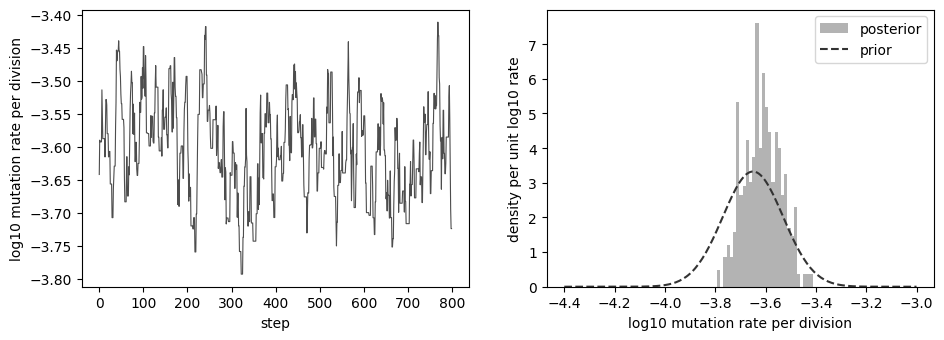

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(range(STEPS), chain, color="0.3", linewidth=0.8)
ax1.set_xlabel("step")
ax1.set_ylabel("log10 mutation rate per division")

ax2.hist(posterior_sample, bins=30, density=True, color="0.7", label="posterior")
grid = [0.0] * 200
prior_curve = [0.0] * 200
for j in range(200):
    grid[j] = -4.4 + j * (1.4 / 199)
    prior_curve[j] = prior(grid[j])
ax2.plot(grid, prior_curve, color="0.2", linestyle="--", label="prior")
ax2.set_xlabel("log10 mutation rate per division")
ax2.set_ylabel("density per unit log10 rate")
ax2.legend()
plt.show()


## 10. Recovery

The counts at the top of this notebook came out of the same simulator, at a rate that can now be named. A procedure that works returns an interval containing it.

Where the posterior centre sits is worth a look. It is not on the true rate, and it is not on the rate the data alone indicate either. It sits between the data and the prior, which is what combining two sources of information is supposed to do.

In [20]:
TRUE_LOG10_MU = -3.50

print(f"rate the data were generated at: {TRUE_LOG10_MU} in log10")
print(f"posterior interval:              {centre - 2 * width:.3f} to {centre + 2 * width:.3f}")
print(f"prior centre:                    {PRIOR_MEAN}")

assert centre - 2 * width < TRUE_LOG10_MU < centre + 2 * width
print("ok, the interval covers the rate the data were generated at")


rate the data were generated at: -3.5 in log10
posterior interval:              -3.758 to -3.468
prior centre:                    -3.65
ok, the interval covers the rate the data were generated at


---

# Part B

Part B is optional and done outside the session.

- **Rejection ABC, for the comparison.** Draw candidate rates from the prior rather than walking, run the simulator at each, and keep the ones whose $p_0$ lands inside the tolerance. The posterior is the same. What differs is how many simulations were spent to get it, and how many of them were spent far from the rates that survive.
- **A flat prior.** Replace `prior` with a function returning a constant and run the chain again. The ratio becomes 1 everywhere, no step is ever turned away by anything but the tolerance, and the posterior moves. Comparing the two centres shows what the published measurement contributed.
- **The tolerance, halved and doubled.** $\varepsilon$ sets the width of the walls the walk is confined to, so the width of the posterior follows it. This is the route that shows why $\varepsilon$ cannot be chosen to taste: a tolerance picked for a narrow answer produces one.
- **The mean as the summary statistic.** Swap `fraction_zero` for `mean` and recalibrate $\varepsilon$ from its spread. The posterior widens, and the chain's behaviour changes, because the statistic it is steering by is one a single jackpot can move.
- **The 1943 counts.** Luria and Delbruck's own tables are published and can be read in. One obstacle has to be dealt with first, and it is the interesting part of the route: their cultures grew to around $10^8$ cells, this simulator grows to 4096, and a rate inferred at the wrong scale is wrong by orders of magnitude.
